In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from zipfile import ZipFile

# Path to the ZIP file
zip_path = Path(r"C:\Users\User\Downloads\diabetes+130-us+hospitals+for+years+1999-2008.zip")

# Ensure the ZIP file exists
if not zip_path.exists():
    raise FileNotFoundError(f"ZIP file not found at: {zip_path}")

# Extract and read the CSV inside the ZIP
with ZipFile(zip_path, 'r') as zip_ref:
    # Get all CSV files inside
    csv_files = [f for f in zip_ref.namelist() if f.endswith('.csv')]
    
    if not csv_files:
        raise ValueError("No CSV file found inside the ZIP archive.")
    
    # If multiple CSVs, choose the first one (you can modify this logic)
    target_csv = csv_files[0]
    print(f"Reading file: {target_csv}")
    
    # Read the CSV directly
    df = pd.read_csv(zip_ref.open(target_csv))

# Display dataset info
print(f"\n✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nSample Data:\n", df.head())

# Clean missing values ('?' → NaN)
df = df.replace('?', np.nan)

# Count missing values
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

print("\n📊 Columns with Missing Values:\n", missing_counts)


Reading file: diabetic_data.csv

✅ Dataset loaded successfully!
Shape: (101766, 50)

Sample Data:
    encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipto

In [3]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# ----------------------
# 1️⃣ Define target and features
# ----------------------
target_col = "readmitted"

# Encode target (binary classification)
df["readmitted_label"] = df[target_col].map({"NO": 0, ">30": 0, "<30": 1})
y = df["readmitted_label"]
X = df.drop(columns=[target_col, "readmitted_label"])

# ----------------------
# 2️⃣ Identify categorical and numerical columns
# ----------------------
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# ----------------------
# 3️⃣ Define preprocessing pipeline
# ----------------------
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

# ----------------------
# 4️⃣ Transform the data
# ----------------------
X_encoded = preprocessor.fit_transform(X)

# Get final feature names
cat_features = preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(cat_cols)
all_features = list(num_cols) + list(cat_features)

X_encoded_df = pd.DataFrame(X_encoded, columns=all_features)

print("✅ Encoded features preview:\n", X_encoded_df.head())
print("\n📊 Target class distribution:\n", y.value_counts())

# ----------------------
# 5️⃣ Feature importance with RandomForest
# ----------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_encoded_df, y)

# Compute importances
importances = pd.Series(rf_model.feature_importances_, index=all_features)
importances = importances.sort_values(ascending=False)

print("\n🔥 Top 20 Important Features:\n", importances.head(20))

# ----------------------
# 6️⃣ Select top 30 features
# ----------------------
top_features = importances.head(30).index.tolist()
print("\n🏆 Top 30 Selected Features:\n", top_features)


✅ Encoded features preview:
    encounter_id  patient_nbr  admission_type_id  discharge_disposition_id  \
0     2278392.0    8222157.0                6.0                      25.0   
1      149190.0   55629189.0                1.0                       1.0   
2       64410.0   86047875.0                1.0                       1.0   
3      500364.0   82442376.0                1.0                       1.0   
4       16680.0   42519267.0                1.0                       1.0   

   admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  \
0                  1.0               1.0                41.0             0.0   
1                  7.0               3.0                59.0             0.0   
2                  7.0               2.0                11.0             5.0   
3                  7.0               2.0                44.0             1.0   
4                  7.0               1.0                51.0             0.0   

   num_medications  number_

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
from zipfile import ZipFile
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# ----------------------
# 1️⃣ Load CSV from ZIP
# ----------------------
zip_path = Path(r"C:\Users\User\Downloads\diabetes+130-us+hospitals+for+years+1999-2008.zip")

if not zip_path.exists():
    raise FileNotFoundError(f"ZIP file not found at: {zip_path}")

with ZipFile(zip_path, 'r') as z:
    csv_files = [f for f in z.namelist() if f.endswith('.csv')]
    if not csv_files:
        raise ValueError("No CSV files found inside the ZIP!")
    csv_name = 'diabetic_data.csv' if 'diabetic_data.csv' in csv_files else csv_files[0]
    print(f"📂 Loading file: {csv_name}")
    df = pd.read_csv(z.open(csv_name))

# ----------------------
# 2️⃣ Identify data types
# ----------------------
target_col = 'readmitted'
cat_cols = df.select_dtypes(include='object').columns.drop(target_col)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# ----------------------
# 3️⃣ Encode target variable
# ----------------------
df['readmitted_label'] = df[target_col].map({'NO': 0, '>30': 0, '<30': 1})
y = df['readmitted_label']
X = df.drop(columns=[target_col, 'readmitted_label'])

# ----------------------
# 4️⃣ Preprocessing BEFORE imputation
# ----------------------
pre_before = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])

X_before = pre_before.fit_transform(X)
cat_features_before = pre_before.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features_before = list(cat_features_before) + list(num_cols)
X_before_df = pd.DataFrame(X_before, columns=all_features_before)

print("\n=== 🧩 Sample Features BEFORE Imputation ===")
print(X_before_df.head())

# ----------------------
# 5️⃣ Preprocessing AFTER imputation
# ----------------------
pre_after = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), cat_cols),
    ('num', SimpleImputer(strategy='median'), num_cols)
])

X_after = pre_after.fit_transform(X)
cat_features_after = pre_after.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features_after = list(cat_features_after) + list(num_cols)
X_after_df = pd.DataFrame(X_after, columns=all_features_after)

print("\n=== 🧩 Sample Features AFTER Imputation ===")
print(X_after_df.head())

# ----------------------
# 6️⃣ RandomForest for Feature Importance
# ----------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_after_df, y)

importances = pd.Series(rf_model.feature_importances_, index=all_features_after)
importances = importances.sort_values(ascending=False)

print("\n🔥 Top 20 Important Features:")
print(importances.head(20))

# ----------------------
# 7️⃣ Select Top 30 Features
# ----------------------
top_30_features = importances.head(30).index.tolist()
print("\n🏆 Top 30 Selected Features:")
print(top_30_features)


📂 Loading file: diabetic_data.csv

=== 🧩 Sample Features BEFORE Imputation ===
   race_AfricanAmerican  race_Asian  race_Caucasian  race_Hispanic  \
0                   0.0         0.0             1.0            0.0   
1                   0.0         0.0             1.0            0.0   
2                   1.0         0.0             0.0            0.0   
3                   0.0         0.0             1.0            0.0   
4                   0.0         0.0             1.0            0.0   

   race_Other  gender_Male  gender_Unknown/Invalid  age_[10-20)  age_[20-30)  \
0         0.0          0.0                     0.0          0.0          0.0   
1         0.0          0.0                     0.0          1.0          0.0   
2         0.0          0.0                     0.0          0.0          1.0   
3         0.0          1.0                     0.0          0.0          0.0   
4         0.0          1.0                     0.0          0.0          0.0   

   age_[30-40)  ...

In [6]:
from sklearn.model_selection import train_test_split
import pandas as pd

# ----------------------
# 1️⃣ Ensure DataFrame & Select Top Features
# ----------------------
# Convert to DataFrame safely
if not isinstance(X_encoded, pd.DataFrame):
    X_encoded_df = pd.DataFrame(X_encoded, columns=all_features)
else:
    X_encoded_df = X_encoded.copy()

# Keep only top N features (from feature importance)
X_top = X_encoded_df.loc[:, top_features]

print(f"✅ Selected {len(top_features)} top features for modeling.")

# ----------------------
# 2️⃣ Train-Test Split
# ----------------------
X_train_top, X_test_top, y_train, y_test = train_test_split(
    X_top,
    y,
    test_size=0.2,
    stratify=y if y.nunique() > 1 else None,  # stratify only if y has >1 class
    random_state=42,
)

# ----------------------
# 3️⃣ Summary Info
# ----------------------
print("\n📊 Dataset Split Summary:")
print(f"Training set: {X_train_top.shape[0]} samples, {X_train_top.shape[1]} features")
print(f"Testing set:  {X_test_top.shape[0]} samples, {X_test_top.shape[1]} features")
print(f"Target distribution (train):\n{y_train.value_counts(normalize=True).round(3)}")


✅ Selected 30 top features for modeling.

📊 Dataset Split Summary:
Training set: 81412 samples, 30 features
Testing set:  20354 samples, 30 features
Target distribution (train):
readmitted_label
0    0.888
1    0.112
Name: proportion, dtype: float64


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ----------------------
# 1️⃣ Prepare Feature Matrix
# ----------------------
# Ensure X_encoded is a DataFrame
X_df = pd.DataFrame(X_encoded, columns=all_features) if not isinstance(X_encoded, pd.DataFrame) else X_encoded.copy()

# Select only top-ranked features
X_top = X_df[top_features]

print(f"✅ Using top {len(top_features)} features for model training.")

# ----------------------
# 2️⃣ Train-Test Split
# ----------------------
# Define split parameters
split_config = {
    "test_size": 0.2,
    "random_state": 42,
    "stratify": y if y.nunique() > 1 else None
}

X_train_top, X_test_top, y_train, y_test = train_test_split(X_top, y, **split_config)

# ----------------------
# 3️⃣ Display Summary
# ----------------------
def summarize_split(X_train, X_test, y_train, y_test):
    print("\n📊 === Train/Test Split Summary ===")
    print(f"Training set: {X_train.shape[0]} rows × {X_train.shape[1]} features")
    print(f"Testing set:  {X_test.shape[0]} rows × {X_test.shape[1]} features")
    print("\n🎯 Target distribution:")
    print(f"Train: \n{y_train.value_counts(normalize=True).round(3)}")
    print(f"\nTest: \n{y_test.value_counts(normalize=True).round(3)}")

summarize_split(X_train_top, X_test_top, y_train, y_test)


✅ Using top 30 features for model training.

📊 === Train/Test Split Summary ===
Training set: 81412 rows × 30 features
Testing set:  20354 rows × 30 features

🎯 Target distribution:
Train: 
readmitted_label
0    0.888
1    0.112
Name: proportion, dtype: float64

Test: 
readmitted_label
0    0.888
1    0.112
Name: proportion, dtype: float64


In [6]:
import pandas as pd
from pathlib import Path
from zipfile import ZipFile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ----------------------
# 1️⃣ Load dataset from ZIP
# ----------------------
zip_path = Path(r"C:\Users\User\Downloads\diabetes+130-us+hospitals+for+years+1999-2008.zip")

if not zip_path.exists():
    raise FileNotFoundError(f"ZIP file not found at: {zip_path}")

with ZipFile(zip_path, "r") as zip_ref:
    csv_files = [f for f in zip_ref.namelist() if f.endswith(".csv")]
    if not csv_files:
        raise ValueError("No CSV file found inside ZIP archive.")
    csv_name = "diabetic_data.csv" if "diabetic_data.csv" in csv_files else csv_files[0]
    print(f"📂 Loading file: {csv_name}")
    df = pd.read_csv(zip_ref.open(csv_name))

# ----------------------
# 2️⃣ Define target and features
# ----------------------
target_col = "readmitted"  # ⚠️ Adjust as needed
X = df.drop(columns=[target_col])
y = df[target_col]

# ----------------------
# 3️⃣ Train-Test Split
# ----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if y.nunique() > 1 else None
)

print(f"✅ Split done: {X_train.shape[0]} train samples, {X_test.shape[0]} test samples.")

# ----------------------
# 4️⃣ Identify Column Types
# ----------------------
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"🔢 Numeric features: {len(num_cols)}")
print(f"🔠 Categorical features: {len(cat_cols)}")

# ----------------------
# 5️⃣ Create Preprocessor
# ----------------------
numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

print("\n⚙️ Preprocessor ready!")


📂 Loading file: diabetic_data.csv
✅ Split done: 81412 train samples, 20354 test samples.
🔢 Numeric features: 13
🔠 Categorical features: 36

⚙️ Preprocessor ready!


In [2]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def get_classification_models(random_state=42):
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            random_state=random_state,
            n_jobs=-1
        ),

        "XGBoost": XGBClassifier(
            n_estimators=300,
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=random_state,
            use_label_encoder=False
        ),

        "LinearSVM": CalibratedClassifierCV(
            estimator=LinearSVC(random_state=random_state),  # 👈 fixed here
            cv=5,
            method="sigmoid"
        ),

        "GradientBoosting": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=3,
            random_state=random_state
        )
    }

    return models


models = get_classification_models(random_state=0)

print("✅ Models initialized:")
for name, model in models.items():
    print(f"• {name}: {model.__class__.__name__}")


✅ Models initialized:
• RandomForest: RandomForestClassifier
• XGBoost: XGBClassifier
• LinearSVM: CalibratedClassifierCV
• GradientBoosting: GradientBoostingClassifier


✅ Dataset loaded successfully!
Shape: (101766, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No   
1                 3  ...          No      Up                   No   
2                 2  ...          No      No                   No   

   glipizide-metformin  glimepiride-pioglitazone  metformin-rosiglitazone  \
0                

,Model,F1 Score,Brier Score,ROC AUC,Train Time (s)
0,RandomForest,0.0139,0.0946,0.6649,238.72
1,XGBoost,0.0732,0.0946,0.6786,3.50
2,LinearSVM,0.0113,0.0962,0.6413,76.83


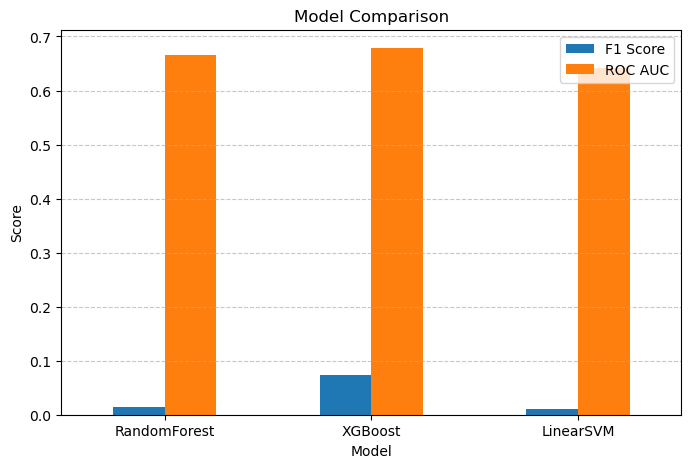

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, brier_score_loss, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# ======================================
# 1️⃣ Load Dataset from ZIP
# ======================================
zip_file_path = r"C:\Users\User\Downloads\diabetes+130-us+hospitals+for+years+1999-2008.zip"

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    csv_file_name = 'diabetic_data.csv'  # check this name inside your ZIP
    df = pd.read_csv(zip_ref.open(csv_file_name))

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head(3))

# ======================================
# 2️⃣ Prepare Features & Target
# ======================================
target_col = 'readmitted'  # target variable
df['readmitted_label'] = df['readmitted'].map({'NO': 0, '>30': 0, '<30': 1})  # binary encoding

X = df.drop(columns=['readmitted', 'readmitted_label'])
y = df['readmitted_label']

# ======================================
# 3️⃣ Train-Test Split
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================================
# 4️⃣ Preprocessing (Numeric + Categorical)
# ======================================
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# ======================================
# 5️⃣ Encode Target
# ======================================
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# ======================================
# 6️⃣ Define Models
# ======================================
models = {
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=0, n_estimators=300),
    "LinearSVM": CalibratedClassifierCV(LinearSVC(random_state=0), cv=5, method="sigmoid")
}

# ======================================
# 7️⃣ Train & Evaluate Models
# ======================================
results = []

for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    start = time.time()

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train_enc)
    train_time = round(time.time() - start, 2)

    # Probabilities / Predictions
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)
        y_proba_final = y_proba[:, 1] if y_proba.shape[1] == 2 else y_proba
    else:
        y_scores = pipeline.decision_function(X_test)
        y_proba_final = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())

    y_pred = pipeline.predict(X_test)

    # Metrics
    if len(np.unique(y_test_enc)) > 2:
        y_test_bin = label_binarize(y_test_enc, classes=np.unique(y_test_enc))
        roc = roc_auc_score(y_test_bin, y_proba_final, average="weighted", multi_class="ovr")
        f1 = f1_score(y_test_enc, y_pred, average="weighted")
        brier = np.nan
    else:
        roc = roc_auc_score(y_test_enc, y_proba_final)
        f1 = f1_score(y_test_enc, y_pred)
        brier = brier_score_loss(y_test_enc, y_proba_final)

    results.append({
        "Model": name,
        "F1 Score": round(f1, 4),
        "Brier Score": round(brier, 4) if not np.isnan(brier) else np.nan,
        "ROC AUC": round(roc, 4),
        "Train Time (s)": train_time
    })

    print(f"✅ {name} -> F1: {f1:.4f}, ROC AUC: {roc:.4f}, Time: {train_time:.2f}s")

# ======================================
# 8️⃣ Results Summary
# ======================================
results_df = pd.DataFrame(results)
display(results_df)

# ======================================
# 9️⃣ Visualization
# ======================================
results_df.plot(x="Model", y=["F1 Score", "ROC AUC"], kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.show()


In [7]:
import pandas as pd
import zipfile
from sklearn.model_selection import train_test_split

zip_file_path = r"C:\Users\User\Downloads\diabetes+130-us+hospitals+for+years+1999-2008.zip"

with zipfile.ZipFile(zip_file_path, 'r') as z:
    csv_file_name = 'diabetic_data.csv'
    df = pd.read_csv(z.open(csv_file_name))

# Replace '?' with NaN
df.replace('?', pd.NA, inplace=True)

# Define target
target_col = 'readmitted'
X = df.drop(columns=[target_col])
y = df[target_col]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Dataset loaded and split successfully!")
print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")


✅ Dataset loaded and split successfully!
Training set: (81412, 49)
Testing set:  (20354, 49)


✅ Dataset loaded!
Shape: (101766, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)    NaN   
1        149190     55629189        Caucasian  Female  [10-20)    NaN   
2         64410     86047875  AfricanAmerican  Female  [20-30)    NaN   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No   
1                 3  ...          No      Up                   No   
2                 2  ...          No      No                   No   

   glipizide-metformin  glimepiride-pioglitazone  metformin-rosiglitazone  \
0                   No        

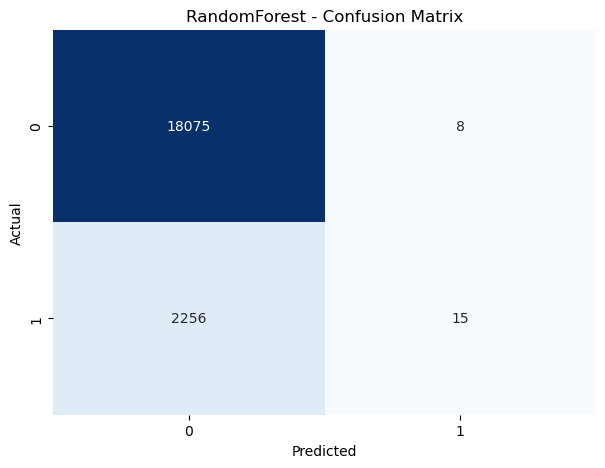


📊 XGBoost Evaluation:
Accuracy: 0.8886, F1: 0.8450, ROC-AUC: 0.6757

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     18083
           1       0.51      0.05      0.08      2271

    accuracy                           0.89     20354
   macro avg       0.70      0.52      0.51     20354
weighted avg       0.85      0.89      0.85     20354



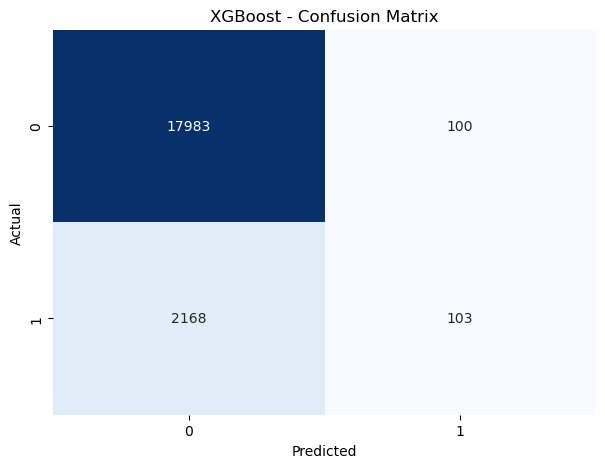


📊 LinearSVM Evaluation:
Accuracy: 0.8881, F1: 0.8371, ROC-AUC: 0.6418

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.41      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.65      0.50      0.48     20354
weighted avg       0.84      0.89      0.84     20354



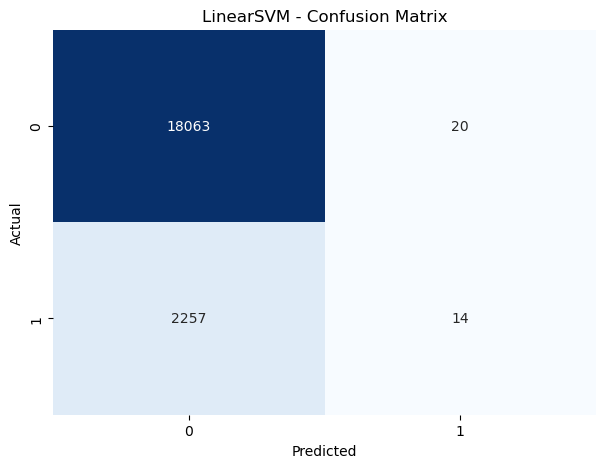

,Model,Accuracy,F1 Score,ROC AUC
0,RandomForest,0.888769,0.837523,0.659862
1,XGBoost,0.888572,0.845015,0.675673
2,LinearSVM,0.888130,0.837104,0.641801


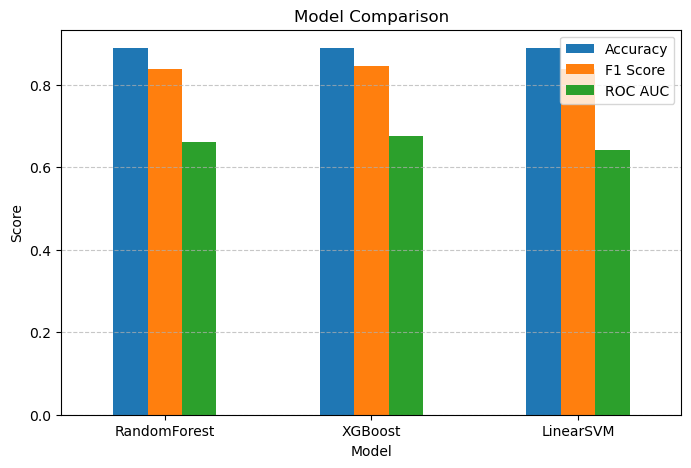

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# ======================================
# 1️⃣ Load Dataset from ZIP
# ======================================
zip_file_path = r"C:\Users\User\Downloads\diabetes+130-us+hospitals+for+years+1999-2008.zip"

with zipfile.ZipFile(zip_file_path, 'r') as z:
    csv_file_name = 'diabetic_data.csv'  # check inside your ZIP
    df = pd.read_csv(z.open(csv_file_name))

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

print("✅ Dataset loaded!")
print("Shape:", df.shape)
print(df.head(3))

# ======================================
# 2️⃣ Prepare Features & Target
# ======================================
target_col = 'readmitted'
df['readmitted_label'] = df['readmitted'].map({'NO': 0, '>30': 0, '<30': 1})

X = df.drop(columns=['readmitted', 'readmitted_label'])
y = df['readmitted_label']

# ======================================
# 3️⃣ Train-Test Split
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================================
# 4️⃣ Preprocessing with Imputation
# ======================================
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# Numeric: median imputation + scaling
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: most frequent imputation + one-hot encoding
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # fill missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# ======================================
# 5️⃣ Encode Target
# ======================================
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# ======================================
# 6️⃣ Define Models
# ======================================
models = {
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=0, n_estimators=300),
    "LinearSVM": CalibratedClassifierCV(LinearSVC(random_state=0), cv=5, method="sigmoid")
}

# ======================================
# 7️⃣ Train All Models & Store in trained_models
# ======================================
trained_models = {}

for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    start_time = time.time()

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train_enc)
    trained_models[name] = pipeline

    print(f"✅ {name} trained in {round(time.time()-start_time, 2)}s")

# ======================================
# 8️⃣ Define Evaluation Function
# ======================================
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    
    if hasattr(model.named_steps["model"], "predict_proba"):
        y_proba = model.predict_proba(X_test)
    else:
        y_proba = None

    # Accuracy & F1
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # ROC-AUC
    if y_proba is not None:
        if y_proba.shape[1] > 2:
            y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
            roc = roc_auc_score(y_test_bin, y_proba, average="weighted", multi_class="ovr")
        else:
            roc = roc_auc_score(y_test, y_proba[:,1])
    else:
        roc = None

    # Print metrics
    print(f"\n📊 {model_name} Evaluation:")
    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}", end="")
    if roc is not None:
        print(f", ROC-AUC: {roc:.4f}")
    else:
        print()

    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {"Model": model_name, "Accuracy": acc, "F1 Score": f1, "ROC AUC": roc}

# ======================================
# 9️⃣ Evaluate All Models
# ======================================
results_list = []
for name, model in trained_models.items():
    results_list.append(evaluate_model(model, X_test, y_test, model_name=name))

# Summary DataFrame
results_df = pd.DataFrame(results_list)
display(results_df)

# Bar chart of metrics
results_df.plot(x="Model", y=["Accuracy", "F1 Score", "ROC AUC"], kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.show()
